## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2022_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2010-01-01,2010,1,2009-12-07,40.592622,22.352330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.592622,22.352330,14316.0,14007.0,40.592622,22.352330,14060.666667,13890.714286,14195.888889,13777.846154,14634.923077,13822.526316,15121.166667,14121.666667,2010-01-01,40.550185,22.350102,0.515309,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.515309,0.515309
1,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2010-01-16,2010,1,2009-12-07,40.592622,22.352330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.592622,22.352330,14212.0,13899.0,40.592622,22.352330,14060.666667,13890.714286,14195.888889,13777.846154,14634.923077,13822.526316,15121.166667,14121.666667,2010-01-16,40.550185,22.350102,27.390689,2010-01-09,2010-01-02,2010-01-09,2010-01-02,6.392266,24.997598
2,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2010-01-01,2010,1,2009-12-07,40.529740,22.392754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.529740,22.392754,14367.0,14071.0,40.529740,22.392754,14085.000000,13912.142857,14191.333333,13765.428571,14612.538462,13891.235294,14977.615385,14140.916667,2010-01-01,40.550185,22.350102,0.515309,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.515309,0.515309
3,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2010-01-16,2010,1,2009-12-07,40.529740,22.392754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.529740,22.392754,14203.0,13927.0,40.529740,22.392754,14085.000000,13912.142857,14191.333333,13765.428571,14612.538462,13891.235294,14977.615385,14140.916667,2010-01-16,40.550185,22.350102,27.390689,2010-01-09,2010-01-02,2010-01-09,2010-01-02,6.392266,24.997598
4,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.56159,2010-01-01,2010,1,2009-12-07,40.561181,22.392754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.561181,22.392754,14355.0,14079.0,40.561181,22.392754,14063.000000,13907.714286,14221.125000,13775.916667,14610.000000,13872.875000,14972.916667,14145.750000,2010-01-01,40.550185,22.350102,0.515309,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.515309,0.515309


In [6]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14316.0,14007.0,14060.666667,13890.714286,14195.888889,13777.846154,14634.923077,13822.526316,15121.166667,14121.666667,0.515309,0.515309,0.515309
1,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14212.0,13899.0,14060.666667,13890.714286,14195.888889,13777.846154,14634.923077,13822.526316,15121.166667,14121.666667,27.390689,6.392266,24.997598
2,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,14071.0,14085.000000,13912.142857,14191.333333,13765.428571,14612.538462,13891.235294,14977.615385,14140.916667,0.515309,0.515309,0.515309
3,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14203.0,13927.0,14085.000000,13912.142857,14191.333333,13765.428571,14612.538462,13891.235294,14977.615385,14140.916667,27.390689,6.392266,24.997598
4,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.56159,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14355.0,14079.0,14063.000000,13907.714286,14221.125000,13775.916667,14610.000000,13872.875000,14972.916667,14145.750000,0.515309,0.515309,0.515309


In [10]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11


### Merge Timeline and WNV Case Files ###

In [11]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['ηρωικης πολεως ναουσας', 'ηρωικης πολης ναουσας']

Length: 2


In [12]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολης ναουσας','ναουσας'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [13]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [14]:
wnv_file.case.sum()

863

In [15]:
wnv_file

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11
...,...,...,...,...
6079,ωραιοκαστρου,κεντρικης μακεδονιας,2022-09-16,0
6080,ωραιοκαστρου,κεντρικης μακεδονιας,2022-10-01,0
6081,ωραιοκαστρου,κεντρικης μακεδονιας,2022-10-16,0
6082,ωραιοκαστρου,κεντρικης μακεδονιας,2022-11-01,0


In [16]:
wnv_file_grouped = wnv_file.groupby(['lau1', 'nuts2', 'dt_placement'], as_index = False)
wnv_file = wnv_file_grouped.sum()
wnv_file

,lau1,nuts2,dt_placement,case
0,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-01,0
1,αλεξανδρειας,κεντρικης μακεδονιας,2010-06-16,0
2,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-01,0
3,αλεξανδρειας,κεντρικης μακεδονιας,2010-07-16,2
4,αλεξανδρειας,κεντρικης μακεδονιας,2010-08-01,11
...,...,...,...,...
5923,ωραιοκαστρου,κεντρικης μακεδονιας,2022-09-16,0
5924,ωραιοκαστρου,κεντρικης μακεδονιας,2022-10-01,0
5925,ωραιοκαστρου,κεντρικης μακεδονιας,2022-10-16,0
5926,ωραιοκαστρου,κεντρικης μακεδονιας,2022-11-01,0


In [17]:
wnv_file.case.sum()

863

In [18]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [19]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14316.0,14007.0,14060.666667,13890.714286,14195.888889,13777.846154,14634.923077,13822.526316,15121.166667,14121.666667,0.515309,0.515309,0.515309,NaN
1,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14212.0,13899.0,14060.666667,13890.714286,14195.888889,13777.846154,14634.923077,13822.526316,15121.166667,14121.666667,27.390689,6.392266,24.997598,NaN
2,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,14071.0,14085.000000,13912.142857,14191.333333,13765.428571,14612.538462,13891.235294,14977.615385,14140.916667,0.515309,0.515309,0.515309,NaN
3,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14203.0,13927.0,14085.000000,13912.142857,14191.333333,13765.428571,14612.538462,13891.235294,14977.615385,14140.916667,27.390689,6.392266,24.997598,NaN
4,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.56159,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14355.0,14079.0,14063.000000,13907.714286,14221.125000,13775.916667,14610.000000,13872.875000,14972.916667,14145.750000,0.515309,0.515309,0.515309,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268939,ωραιοκαστρου,κεντρικης μακεδονιας,22.84892,40.79192,2022-12-16,2022,12,0.138904,-0.092451,-0.097999,0.092451,0.216444,-0.081890,-0.187402,0.081890,0.086855,0.062615,0.085735,0.062615,14251.0,13809.0,13990.444444,13597.050000,14264.384615,13741.285714,14431.375000,13704.941176,14791.529412,14085.312500,1056.208873,8.328537,8.750579,NaN
268940,ωραιοκαστρου,κεντρικης μακεδονιας,22.97330,40.76048,2022-12-01,2022,12,0.224578,-0.123006,-0.230325,0.123006,0.224343,-0.130492,-0.234240,0.130492,0.059263,0.049082,0.029618,0.049082,14316.0,13808.0,14026.000000,13560.631579,14326.500000,13656.857143,14466.857143,13649.058824,14832.058824,14000.500000,977.700661,11.707804,13.303774,NaN
268941,ωραιοκαστρου,κεντρικης μακεδονιας,22.97330,40.76048,2022-12-16,2022,12,0.224578,-0.123006,-0.230325,0.123006,0.224343,-0.130492,-0.234240,0.130492,0.059263,0.049082,0.029618,0.049082,14353.0,13808.0,14026.000000,13560.631579,14326.500000,13656.857143,14466.857143,13649.058824,14832.058824,14000.500000,985.487502,7.662622,7.786842,NaN
268942,ωραιοκαστρου,κεντρικης μακεδονιας,22.84892,40.76048,2022-12-01,2022,12,0.270131,-0.105390,-0.291521,0.105390,0.265473,-0.105137,-0.277477,0.105137,0.074707,0.066116,0.048071,0.066116,14345.0,13911.0,14018.470588,13680.222222,14284.583333,13819.230769,14410.117647,13767.470588,14861.611111,14145.333333,1047.458294,8.083289,10.475563,NaN


In [20]:
merged = fillna(merged,{'case': 0})

In [21]:
merged['case'].value_counts()

0.0     259342
1.0       5538
2.0       1888
3.0        918
4.0        459
         ...  
9.0         41
18.0        30
12.0        30
11.0        23
10.0        22
Name: case, Length: 14, dtype: int64

In [22]:
merged.case.sum()

19669.0

In [23]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.461974,40.604462,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14271.227273,14013.909091,14023.108550,13869.825758,14175.149928,13766.092102,14598.942758,13878.972047,15053.081918,14129.274190,0.201406,0.201406,0.201406,0.0
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,22.077217,41.015220,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14162.000000,13952.425926,13916.559105,13702.385299,13958.985534,13690.115865,14386.631567,13768.235147,14681.525215,13996.048084,0.096034,0.096034,0.096034,0.0
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.000000,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0.0
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.959003,40.911957,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14282.333333,14058.933333,14053.284444,13851.559444,14174.772323,13783.828788,14430.582456,13847.076840,14709.797849,14091.013981,0.036767,0.036767,0.036767,0.0
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.697466,40.495934,2010.0,1.0,0.187515,0.122263,-0.006515,-0.122263,0.155857,0.132800,0.032298,-0.132800,0.018865,0.020253,0.039362,0.020253,14416.055556,14076.750000,14127.831560,13942.129993,14089.923060,13824.937724,14421.077538,13863.772206,14613.843988,14066.394275,1.425578,1.425578,1.425578,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11851,2022-12-16,σιθωνιας,κεντρικης μακεδονιας,23.879555,40.083022,2022.0,12.0,0.306566,0.296238,-0.150733,-0.296238,0.319302,0.284560,-0.167014,-0.284560,0.043412,0.047088,0.044676,0.047088,14437.647059,13994.823529,14071.365629,13772.141295,14222.602715,13884.230365,14336.029508,13824.045539,14666.878518,14166.116335,1604.998398,11.436823,12.953540,0.0
11852,2022-12-16,σιντικης,κεντρικης μακεδονιας,23.287979,41.288407,2022.0,12.0,0.329914,0.032889,-0.292500,-0.032889,0.330727,0.026612,-0.299034,-0.026612,0.052705,0.052188,0.052209,0.052188,14187.456140,13986.298246,13927.966667,13575.289185,14193.174360,13735.442229,14320.202218,13687.960610,14719.740631,14084.052753,891.450977,5.039068,5.108015,0.0
11853,2022-12-16,σκυδρας,κεντρικης μακεδονιας,22.172368,40.796740,2022.0,12.0,0.414913,0.095729,-0.321940,-0.095729,0.392849,0.076643,-0.299592,-0.076643,0.047315,0.042572,0.041469,0.042572,14420.000000,14004.666667,14127.208730,13621.991562,14432.882021,13757.466972,14554.338675,13714.340079,14939.222374,14056.104464,1078.518364,1.842212,2.292425,0.0
11854,2022-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.655951,40.737843,2022.0,12.0,0.177833,-0.136700,-0.187425,0.136700,0.191615,-0.140054,-0.203257,0.140054,0.056623,0.052367,0.040110,0.052367,14332.357143,13845.142857,14049.793090,13619.080311,14380.002289,13756.712883,14461.331182,13722.453854,15037.878449,14091.945003,1012.702695,7.501281,7.768837,0.0


In [24]:
dataset.case.sum()

863.0

In [25]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset = dataset.astype({'case': 'int'})
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)
lau1_map = lau1_mapping(dataset, 0, 0)

In [26]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

### Add mosqutio predictions using trained model ###

In [28]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [29]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [30]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [31]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [32]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [33]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [34]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [35]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

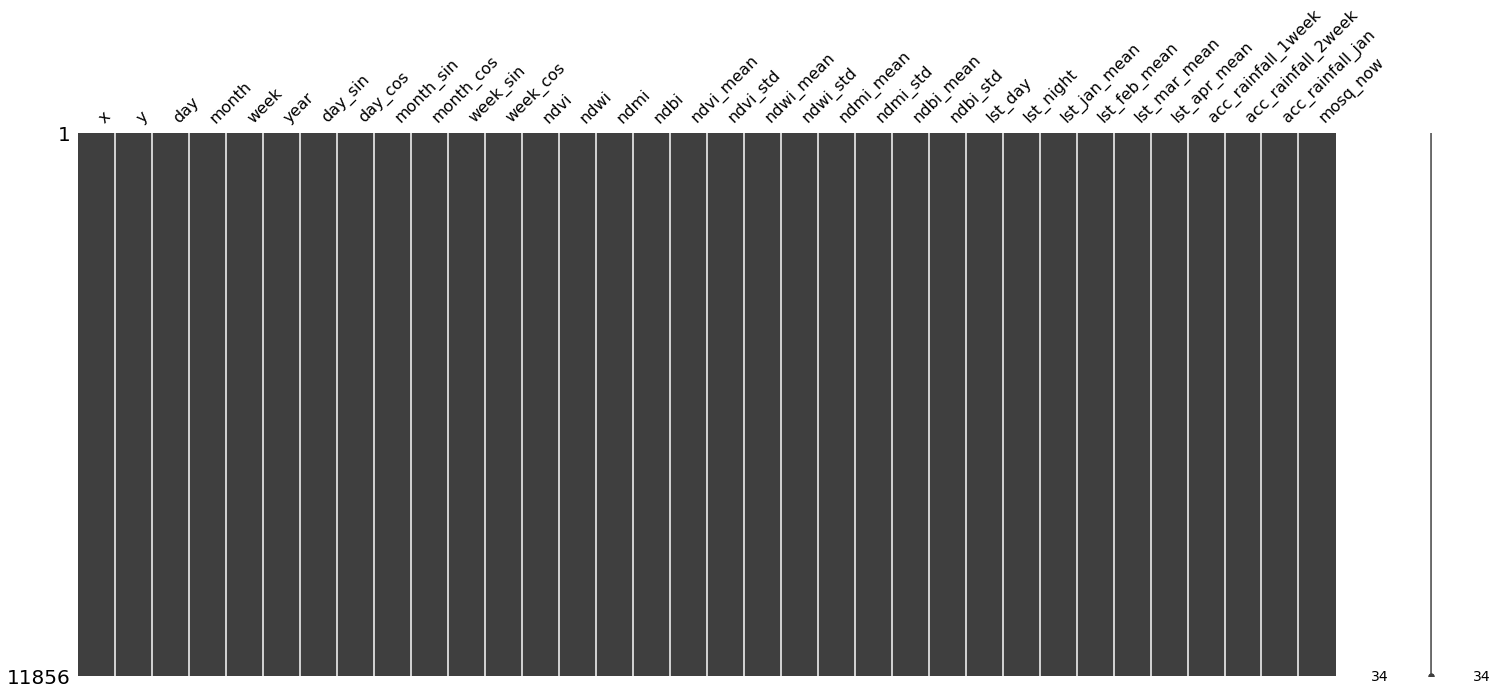

In [36]:
missingno.matrix(dataset_mamoth)

In [37]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [38]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [39]:
predictions = give_predictions(model, dataset_mamoth)

In [40]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.46197,40.60446,2010-01-01,12
1,22.07722,41.01522,2010-01-01,11
2,22.89198,40.65603,2010-01-01,15
3,23.95900,40.91196,2010-01-01,4
4,23.69747,40.49593,2010-01-01,13
...,...,...,...,...
11851,23.87955,40.08302,2022-12-16,1
11852,23.28798,41.28841,2022-12-16,9
11853,22.17237,40.79674,2022-12-16,23
11854,22.65595,40.73784,2022-12-16,4


<AxesSubplot:>

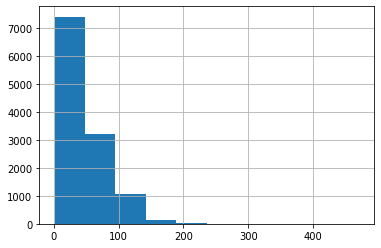

In [41]:
mosqutio_predictions.mosq_pred.hist()

In [42]:
#This cell writes the mosquito predictions to a seperate .csv file

# mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [43]:
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

mosqutio_predictions['x.approx'] = mosqutio_predictions['x'].apply(lambda x : round(x,5))
mosqutio_predictions['y.approx'] = mosqutio_predictions['y'].apply(lambda x : round(x,5))

In [44]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

In [45]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)

In [46]:
dataset.distance.max()

0.0

In [48]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [49]:
dataset.reset_index(inplace=True, drop=True)

<AxesSubplot:>

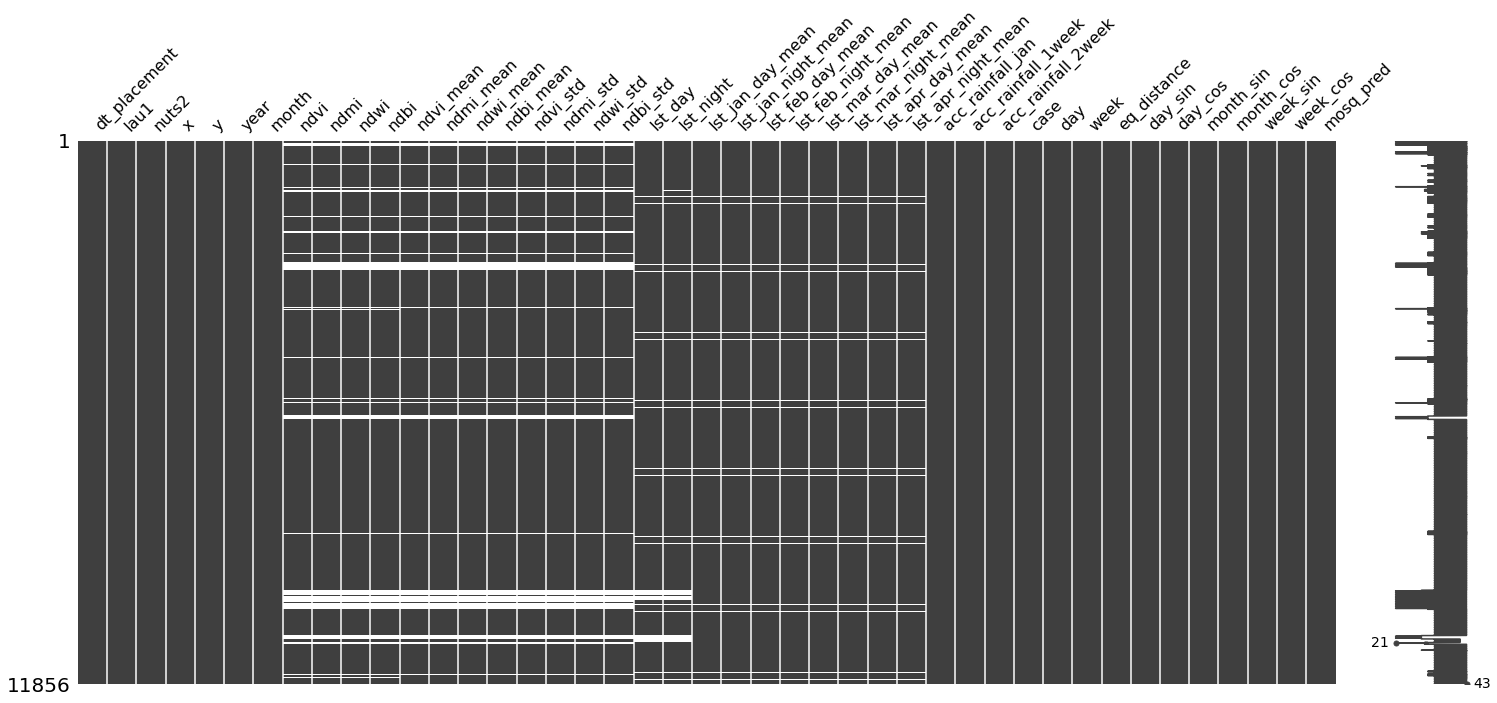

In [50]:
missingno.matrix(dataset)

### Adds demographic features ###

In [51]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [52]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [53]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [54]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [55]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [56]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ναουσας']

Length: 1


In [57]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [58]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [59]:
dataset.case.sum()

863

In [60]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

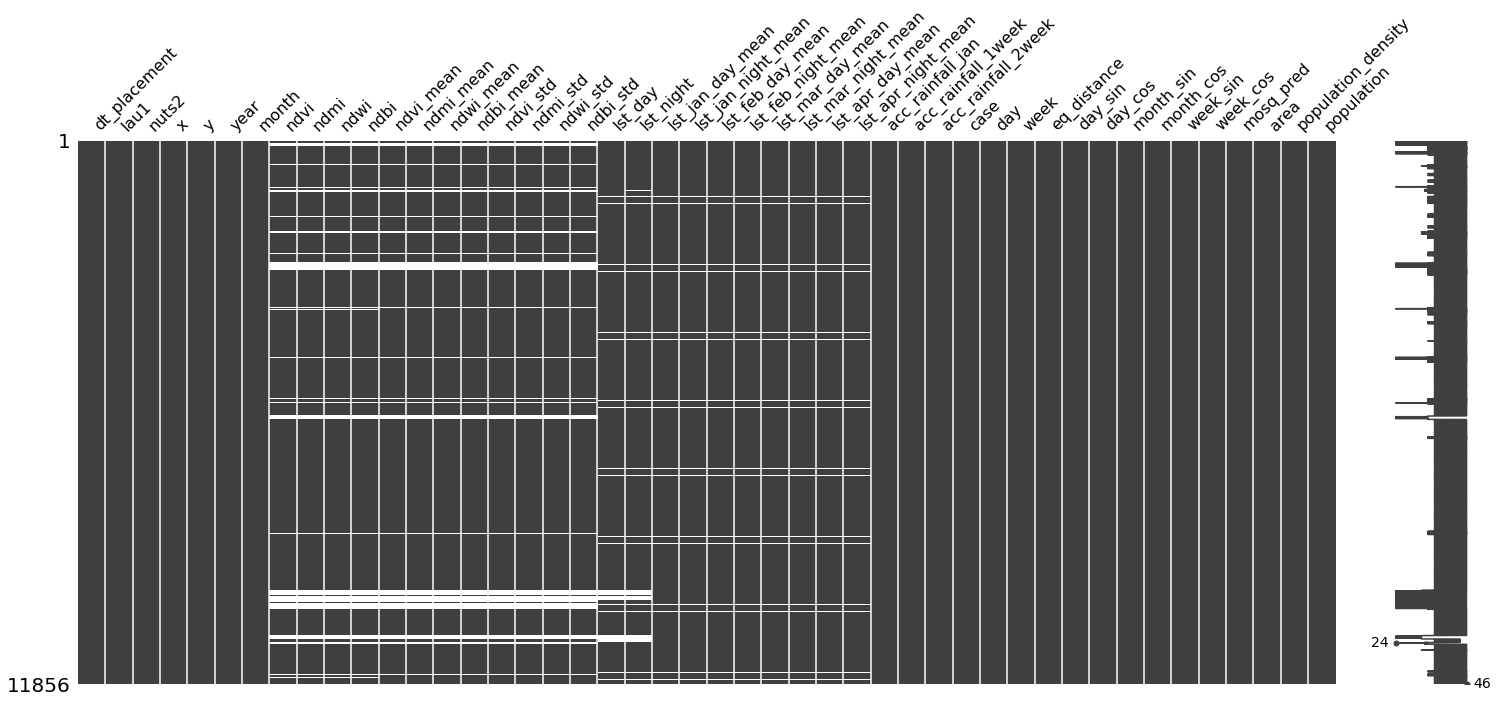

In [61]:
missingno.matrix(dataset)

In [62]:
missing = describe_dataframe(dataset)

In [63]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,area,population_density,population
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.46197,40.60446,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14271.227273,14013.909091,14023.108550,13869.825758,14175.149928,13766.092102,14598.942758,13878.972047,15053.081918,14129.274190,0.201406,0.201406,0.201406,0,1,53,46.40326,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,12,478.8,86.8,38293.0
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,22.07722,41.01522,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14162.000000,13952.425926,13916.559105,13702.385299,13958.985534,13690.115865,14386.631567,13768.235147,14681.525215,13996.048084,0.096034,0.096034,0.096034,0,1,53,46.57952,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,11,985.8,28.0,24924.0
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.000000,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000,0,1,53,46.65786,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,15,9.8,5319.1,49674.0
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.95900,40.91196,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14282.333333,14058.933333,14053.284444,13851.559444,14174.772323,13783.828788,14430.582456,13847.076840,14709.797849,14091.013981,0.036767,0.036767,0.036767,0,1,53,47.41120,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,4,411.8,22.3,7169.0
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.69747,40.49593,2010,1,0.187515,0.122263,-0.006515,-0.122263,0.155857,0.132800,0.032298,-0.132800,0.018865,0.020253,0.039362,0.020253,14416.055556,14076.750000,14127.831560,13942.129993,14089.923060,13824.937724,14421.077538,13863.772206,14613.843988,14066.394275,1.425578,1.425578,1.425578,0,1,53,46.92004,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,13,747.0,24.5,16994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11851,2022-12-16,σιθωνιας,κεντρικης μακεδονιας,23.87955,40.08302,2022,12,0.306566,0.296238,-0.150733,-0.296238,0.319302,0.284560,-0.167014,-0.284560,0.043412,0.047088,0.044676,0.047088,14437.647059,13994.823529,14071.365629,13772.141295,14222.602715,13884.230365,14336.029508,13824.045539,14666.878518,14166.116335,1604.998398,11.436823,12.953540,0,16,50,46.65706,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,1,516.8,24.0,11631.0
11852,2022-12-16,σιντικης,κεντρικης μακεδονιας,23.28798,41.28841,2022,12,0.329914,0.032889,-0.292500,-0.032889,0.330727,0.026612,-0.299034,-0.026612,0.052705,0.052188,0.052209,0.052188,14187.456140,13986.298246,13927.966667,13575.289185,14193.174360,13735.442229,14320.202218,13687.960610,14719.740631,14084.052753,891.450977,5.039068,5.108015,0,16,50,47.40319,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,9,1103.4,20.1,18532.0
11853,2022-12-16,σκυδρας,κεντρικης μακεδονιας,22.17237,40.79674,2022,12,0.414913,0.095729,-0.321940,-0.095729,0.392849,0.076643,-0.299592,-0.076643,0.047315,0.042572,0.041469,0.042572,14420.000000,14004.666667,14127.208730,13621.991562,14432.882021,13757.466972,14554.338675,13714.340079,14939.222374,14056.104464,1078.518364,1.842212,2.292425,0,16,50,46.43262,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,23,239.5,84.3,18080.0
11854,2022-12-16,χαλκηδονος,κεντρικης μακε

In [64]:
dataset.case.sum()

863

In [65]:
dataset = calculate_mosq_previous(dataset)

In [66]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

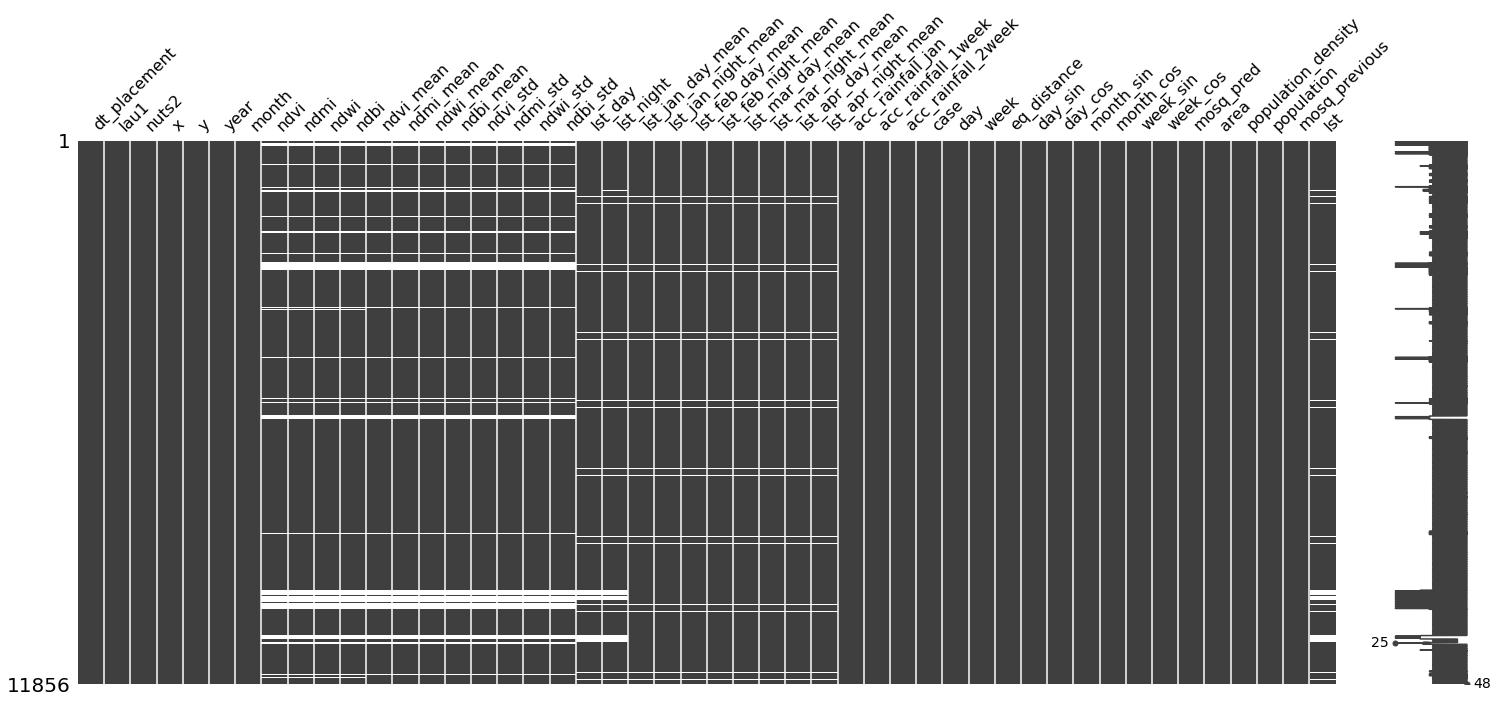

In [67]:
missingno.matrix(dataset)

In [68]:
dataset['case'].value_counts()

0     11414
1       270
2        78
3        36
4        30
      ...  
11        2
9         2
18        1
12        1
10        1
Name: case, Length: 14, dtype: int64

In [69]:
dataset.case.sum()

863

In [70]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [71]:
dataset = convert_multiple_cases(dataset)

In [72]:
dataset['case'].value_counts()

0    11414
1      863
Name: case, dtype: int64

In [73]:
dataset.case.sum()

863

In [74]:
cols = dataset.columns

In [75]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'mosq_pred', 'area',
       'population_density', 'population', 'mosq_previous', 'lst'],
      dtype='object')

In [76]:
len(cols)

48

In [77]:
# check columns

In [78]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [79]:
len(rearranged_columns)

48

In [80]:
dataset = dataset[rearranged_columns].copy()

In [81]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,478.8,38293.0,86.8,46.40326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.701364,12.274545,7.128182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.201406,0.201406,0.201406,12,0,0
1,22.07722,41.01522,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,985.8,24924.0,28.0,46.57952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.994259,10.090000,5.898519,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,0.096034,0.096034,0.096034,11,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,15,0,0
3,23.95900,40.91196,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,411.8,7169.0,22.3,47.41120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.262667,12.496667,8.028667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,0.036767,0.036767,0.036767,4,0,0
4,23.69747,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.979530,0.500000,0.866025,-2.449294e-16,1.000000,747.0,16994.0,24.5,46.92004,0.187515,0.122263,-0.006515,-0.122263,0.155857,0.132800,0.032298,-0.132800,0.018865,0.020253,0.039362,0.020253,11.778056,15.171111,8.385000,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,1.425578,1.425578,1.425578,13,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12272,22.46197,40.60446,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,478.8,38293.0,86.8,46.40326,0.617572,0.270331,-0.536213,-0.270331,0.594201,0.257659,-0.520467,-0.257659,0.060674,0.063398,0.044711,0.063398,25.904545,32.335455,19.473636,8.278138,-1.417295,15.688573,1.198610,17.495392,1.700570,30.950457,9.115382,28.541369,30.206736,693.669942,85,147,1
12273,22.46197,40.60446,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,478.8,38293.0,86.8,46.40326,0.617572,0.270331,-0.536213,-0.270331,0.594201,0.257659,-0.520467,-0.257659,0.060674,0.063398,0.044711,0.063398,25.904545,32.335455,19.473636,8.278138,-1.417295,15.688573,1.198610,17.495392,1.700570,30.950457,9.115382,28.541369,30.206736,693.669942,85,147,1
12274,22.46197,40.60446,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,478.8,38293.0,86.8,46.40326,0.617572,0.270331,-0.536213,-0.270331,0.594201,0.257659,-0.520467,-0.257659,0.060674,0.063398,0.044711,0.063398,25.904545,32.335455,19.473636,8.278138,-1.417295,15.688573,1.198610,17.495392,1.700570,30.950457,9.115382,28.541369,30.206736,693.669942,85,147,1
12275,22.46197,40.60446,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-0.866025,-0.500000,-6.965510e-01,-0.717507,478.8,38293.0,86.8,46.40326,0.617572,0.270331,-0.536213,-0

### Add geomorphological features ###

In [82]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [83]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 8.200838003125297


In [84]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [85]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.46197,40.60446,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.40326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.701364,12.274545,7.128182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.201406,0.201406,0.201406,12,0,0,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071
1,22.07722,41.01522,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.57952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.994259,10.090000,5.898519,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,0.096034,0.096034,0.096034,11,0,0,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,15,0,0,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007
3,23.95900,40.91196,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.41120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.262667,12.496667,8.028667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,0.036767,0.036767,0.036767,4,0,0,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784
4,23.69747,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.92004,0.187515,0.122263,-0.006515,-0.122263,0.155857,0.1328,0.032298,-0.1328,0.018865,0.020253,0.039362,0.020253,11.778056,15.171111,8.385000,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,1.425578,1.425578,1.425578,13,0,0,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661


<AxesSubplot:>

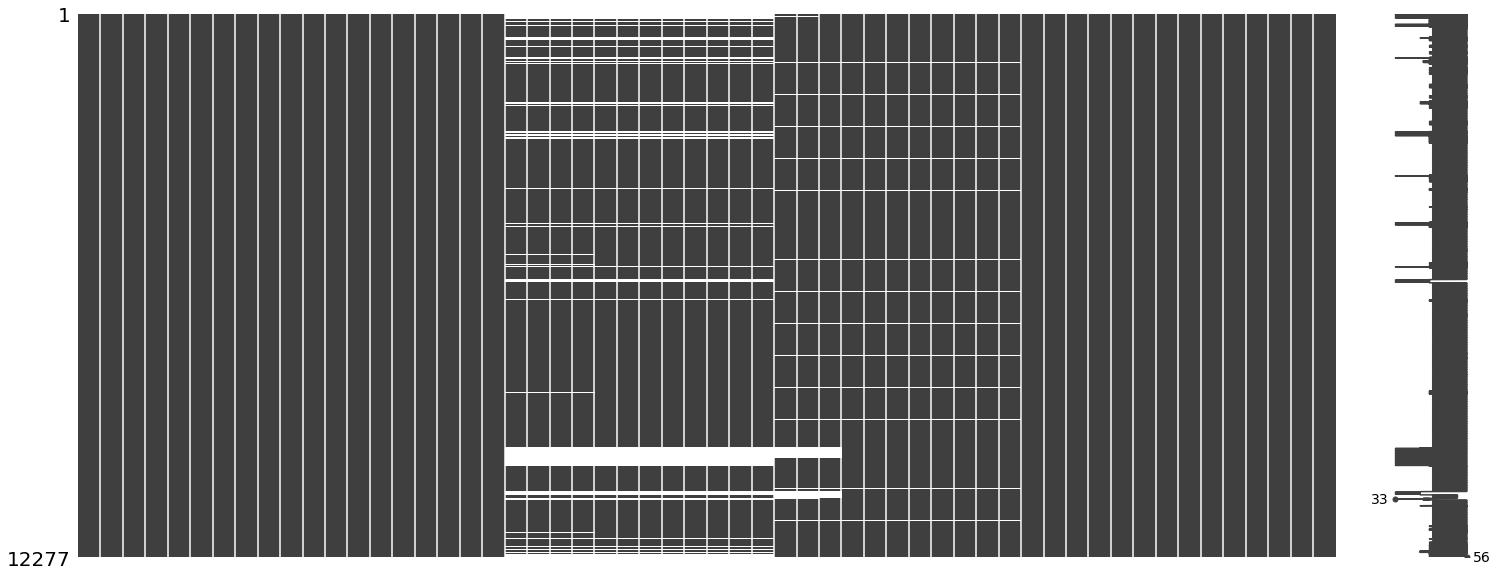

In [86]:
missingno.matrix(dataset)

In [87]:
cols = dataset.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [88]:
len(cols)

56

In [89]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [90]:
len(rearranged_columns)

56

In [91]:
dataset = dataset[rearranged_columns]

In [92]:
dataset.case.sum()

863

### Add Landcover features ###

In [93]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [94]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [95]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [96]:
data_years = dataset['year'].unique().tolist()

In [97]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [98]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2011
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2012
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2013
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2014
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2015
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2016
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2017
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2018
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2019
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2020
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2021
Min distance: 0.0
Max distance: 8.200838003125297
Year: 2022
Min distance: 0.0
Max distance: 8.200838003125297


In [99]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

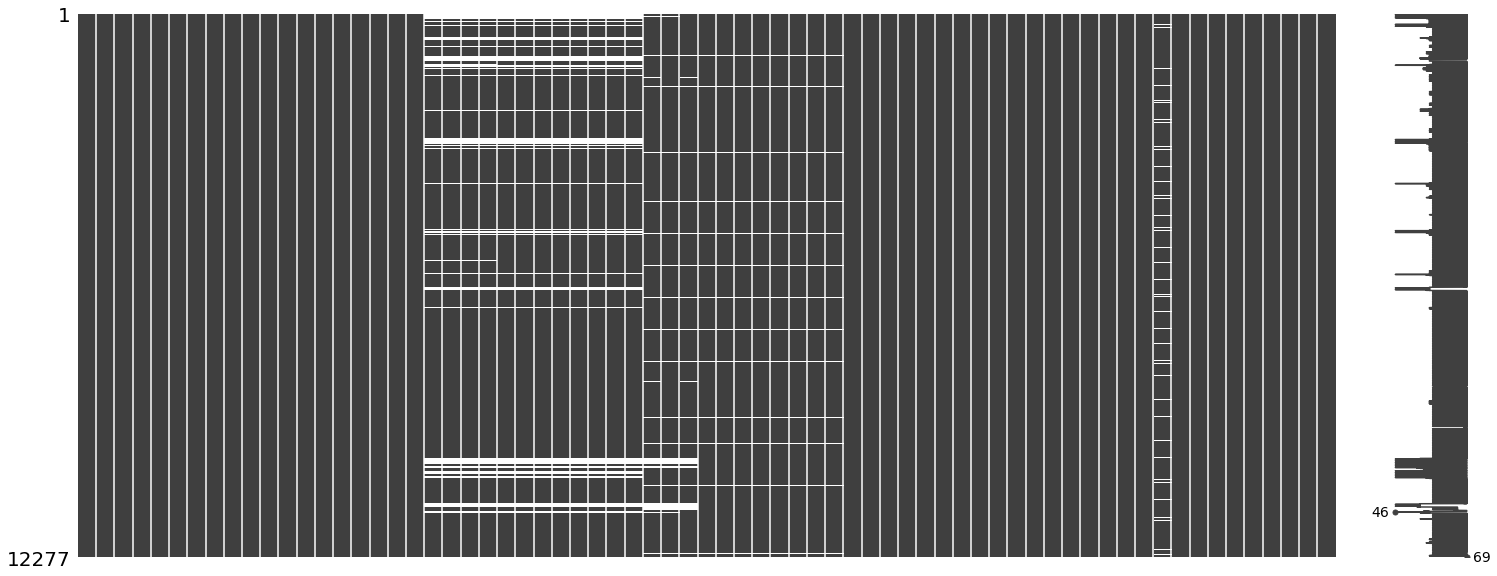

In [100]:
missingno.matrix(dataset_final)

In [101]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case',
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment',
       'lc_prop3', 'lc_prop3_assessment', '

In [102]:
len(cols)

69

In [103]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [104]:
len(rearranged)

69

In [105]:
dataset_final = dataset_final[rearranged]

In [106]:
dataset_final.case.sum()

863

In [107]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv", encoding = enc, index = False)